# Real-time score following experiments

The following Jupyter notebook contains experiments, which evaluate different models against real-time score following problem. These models are:

- OTW
- CYOLO-SB+A
- HeurMiT
- Transformer

Evaluation is performed with the use of selected pieces from MAESTRO dataset, while for specific synthetic experiments it uses custom pieces emphasizing potential pain points in these models.

## 0. Preparation

First let's define modules to import, hyperparameters of the experiments, locate MAESTRO dataset and prepare the models that are evaluated.

In [1]:
import os.path
from typing import Dict, List, Tuple

import evaluation.evaluator
from evaluation.data import ExperimentVariation
from evaluation.evaluator import Evaluator
from evaluation.metrics import MetricKeys, EvaluationMetrics
from experiments.experiments_runner import ExperimentsRunner
from models.cnn_model import HeurMiTModel
from models.cyolo_model import CYOLOModel
from models.otw_model import OTWModel
from experiments.maestro_reader import get_maestro_test_pairs
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from models.transformer_model import TransformerModel

In [2]:
MAESTRO_PATH = r"C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0"
N_PIECES = 2
MAX_DURATION = 500
FIGURES_OUTPUT = "./figures"
RESULTS_OUTPUT = "./results"
BASIC_METRICS = [MetricKeys.ACCURACY, MetricKeys.MEAN_LATENCY, MetricKeys.MEAN_ERROR]
METRIC_NAMES = {
    MetricKeys.ACCURACY: "Dokładność (%)",
    MetricKeys.MEAN_LATENCY: "Średnie opóźnienie (ms)",
    MetricKeys.MEAN_ERROR: "Średni błąd (s)"
}

plt.style.use('default')

os.makedirs(FIGURES_OUTPUT, exist_ok=True)

otw = OTWModel()
cyolo = CYOLOModel()

E:\source\studies\PDYM\score-following-eval\models\cyolo_model.py:157: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _alias):
E:\source\studies\PDYM\score-following-eval\models\cyolo_model.py:157: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _alias):


Conditioning: ContextConditioning | Parameters: {'n_lstm_layers': 1, 'activation': 'nn.ELU', 'zdim': 128, 'normalize_input': True}
Using input normalization!


### 0.1. Train HeurMiT model

In [3]:
HEURMIT_CHECKPOINT_PATH = 'heurmit.pth'

heurMiT = HeurMiTModel()
if not os.path.exists(HEURMIT_CHECKPOINT_PATH):
    heurMiT.train({'dataset_path': MAESTRO_PATH, 'save_path': HEURMIT_CHECKPOINT_PATH})

heurMiT.load_checkpoint(HEURMIT_CHECKPOINT_PATH)

[HeurMiT] device=cuda  c=512  w=256  fps=100  inf_c=512  inf_w=256  params=49,280
[HeurMiT] Loaded checkpoint 'heurmit.pth'.


### 0.2. Train Transformer model

In [4]:
TRANSFORMER_CHECKPOINT_PATH = 'transformer.pth'

transformer = TransformerModel()
if not os.path.exists(TRANSFORMER_CHECKPOINT_PATH):
    transformer.train({'dataset_path': MAESTRO_PATH, 'save_path': TRANSFORMER_CHECKPOINT_PATH})

transformer.load_checkpoint(TRANSFORMER_CHECKPOINT_PATH)

[PatchFormer] d_model=128  patch_size=4  n_layers=2  c=512  w=128  N_ctx=128  N_win=32  N_valid=97  params=661,248
[PatchFormer] Loading MAESTRO train split from 'C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0' …
[PatchFormer] Found 962 train pairs.
[PatchFormer] Pre-computing CQT cache (250 files) → C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\cqt_cache …
[PatchFormer] Pre-computing piano-roll cache (250 files) → C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\roll_cache …
[PatchFormer] Cached pairs ready: 250 pieces (mmap-backed).


E:\source\studies\PDYM\score-following-eval\models\transformer\network.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
E:\source\studies\PDYM\score-following-eval\models\transformer_model.py:430: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
E:\source\studies\PDYM\score-following-eval\models\transformer_model.py:466: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

[PatchFormer] Ep   1/50  tr_loss=8.4114  tr_acc=3.0%  val_loss=4.8707  val_acc=2.9%
[PatchFormer] Ep   2/50  tr_loss=4.8159  tr_acc=3.2%  val_loss=4.6158  val_acc=3.2%
[PatchFormer] Ep   3/50  tr_loss=4.6753  tr_acc=3.7%  val_loss=4.5189  val_acc=5.7%
[PatchFormer] Ep   4/50  tr_loss=4.6869  tr_acc=4.3%  val_loss=4.4893  val_acc=7.9%
[PatchFormer] Ep   5/50  tr_loss=4.7082  tr_acc=4.4%  val_loss=4.5247  val_acc=5.8%
[PatchFormer] Ep   6/50  tr_loss=4.6339  tr_acc=4.8%  val_loss=4.4239  val_acc=6.8%
[PatchFormer] Ep   7/50  tr_loss=4.5520  tr_acc=5.3%  val_loss=4.3567  val_acc=7.8%
[PatchFormer] Ep   8/50  tr_loss=4.5106  tr_acc=5.9%  val_loss=4.3036  val_acc=8.7%
[PatchFormer] Ep   9/50  tr_loss=4.4830  tr_acc=6.2%  val_loss=4.2706  val_acc=7.0%
[PatchFormer] Ep  10/50  tr_loss=4.4446  tr_acc=6.9%  val_loss=4.1950  val_acc=9.9%
[PatchFormer] Ep  11/50  tr_loss=4.4035  tr_acc=7.5%  val_loss=4.1152  val_acc=10.8%
[PatchFormer] Ep  12/50  tr_loss=4.3564  tr_acc=8.2%  val_loss=4.0812  val_

### 0.3. Initialize runner

In [5]:
models = [otw, cyolo, heurMiT, transformer]
evaluator = Evaluator()
experiments_runner = ExperimentsRunner(evaluator, models)

Evaluator initialized (tolerance: 0.5s)


In [6]:
pieces = get_maestro_test_pairs(MAESTRO_PATH, max_pieces=N_PIECES, max_duration=MAX_DURATION)

## 1. Single-dimensional evaluation

This section contains experiments, which perform the simplest evaluation. Each model is tested against a single metric from the selected:

- **mean accuracy** - factor of accurate estimations of current position in each audio frame (tolerance: 500ms)
- **mean latency** - average time needed to process a single audio frame
- **mean error** - average discrepancy between estimated and real position for each audio frame
- **tempo robustness** - factor of accurately estimated tempo values in each audio frame (tolerance: 10% reference BPM).

First, let's run the evaluation to collect all the base metrics.

In [7]:
def extract_single_metric_results(metrics: Dict[str, EvaluationMetrics], metric_key: MetricKeys) -> Dict[str, float]:
    results_for_metric: Dict[str, float] = {}

    for model_name in metrics:
        results_for_metric[model_name] = metrics[model_name].to_dict()[metric_key]

    return results_for_metric

In [8]:
results = experiments_runner.test_average_metrics(
    pieces,
    results_path=os.path.join(RESULTS_OUTPUT, "1_basic_metrics.csv"),
    verbose=True)

Evaluating piece no. 1... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav):   0%|          | 0/2 [00:00<?, ?it/s]E:\source\studies\PDYM\score-following-eval\.venv\Lib\site-packages\torch\functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\SpectralOps.cpp:879.)
  return _VF.stft(  # type: ignore[attr-defined]
E:\source\studies\PDYM\score-following-eval\.venv\Lib\site-packages\torch\functional.p

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s


E:\source\studies\PDYM\score-following-eval\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
E:\source\studies\PDYM\score-following-eval\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=4096 is too large for input signal of length=1024
  warnings.warn(
E:\source\studies\PDYM\score-following-eval\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=4096 is too large for input signal of length=2048
  warnings.warn(
E:\source\studies\PDYM\score-following-eval\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=4096 is too large for input signal of length=3072
  warnings.warn(


[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s  ref_patches=4852


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav):  50%|█████     | 1/2 [01:52<01:52, 112.73s/it]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s  ref_patches=7816


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav): 100%|██████████| 2/2 [04:35<00:00, 137.77s/it]


### 1.1. Mean accuracy

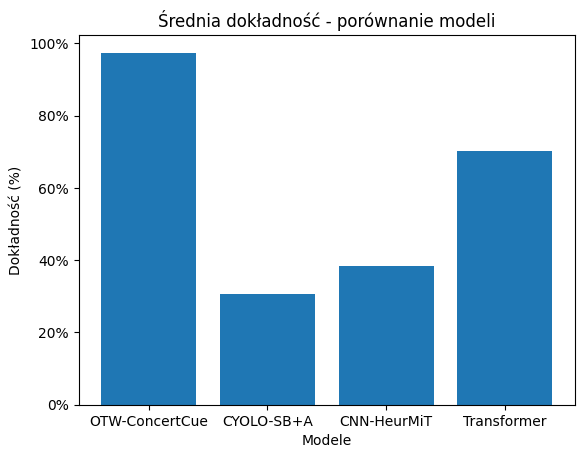

In [9]:
accuracy_results = extract_single_metric_results(results, MetricKeys.ACCURACY)

labels = list(accuracy_results.keys())
values = list(accuracy_results.values())

plt.figure()
plt.bar(labels, values)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xlabel("Modele")
plt.ylabel(METRIC_NAMES[MetricKeys.ACCURACY])
plt.title("Średnia dokładność - porównanie modeli")

plt.savefig(os.path.join(FIGURES_OUTPUT, "1.1_accuracy.png"))
plt.show()

### 1.2. Mean latency

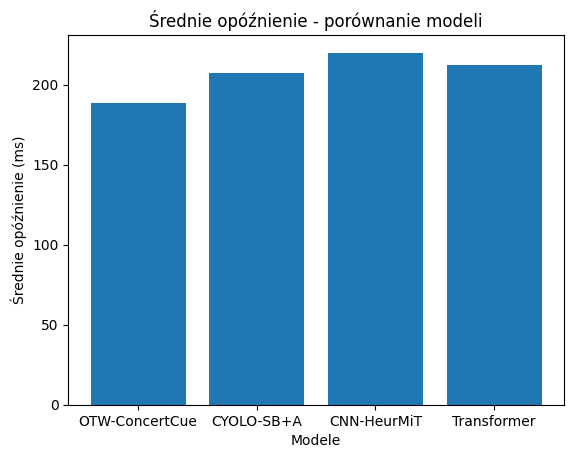

In [10]:
latency_results = extract_single_metric_results(results, MetricKeys.MEAN_LATENCY)

labels = list(latency_results.keys())
values = list(latency_results.values())

plt.figure()
plt.bar(labels, values)

plt.xlabel("Modele")
plt.ylabel(METRIC_NAMES[MetricKeys.MEAN_LATENCY])
plt.title("Średnie opóźnienie - porównanie modeli")

plt.savefig(os.path.join(FIGURES_OUTPUT, "1.2_latency.png"))
plt.show()

### 1.3. Mean error

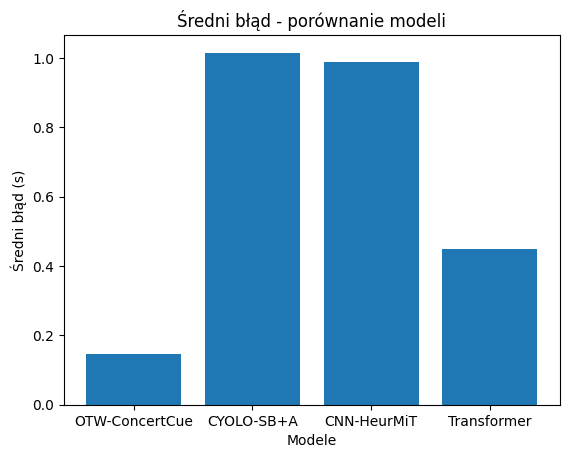

In [11]:
error_results = extract_single_metric_results(results, MetricKeys.MEAN_ERROR)

labels = list(error_results.keys())
values = list(error_results.values())

plt.figure()
plt.bar(labels, values)

plt.xlabel("Modele")
plt.ylabel(METRIC_NAMES[MetricKeys.MEAN_ERROR])
plt.title("Średni błąd - porównanie modeli")

plt.savefig(os.path.join(FIGURES_OUTPUT, "1.3_error.png"))
plt.show()

## 2. Two-dimensional evaluation

In the following experiments it is evaluated how models perform when some audio transformation is applied to the original track with different factor. The base metrics are collected for the following transformations:

- tempo change
- pitch shift
- noise addition

Each transformation has 10 different factors applied, together with single no transformation evaluation.

In [12]:
def extract_labels_and_values_for_experiment_variations(
        variations: List[ExperimentVariation], metric_key: MetricKeys
) -> Tuple[List[float], List[float]]:
    l = [variation.factor for variation in variations]
    v = [variation.result.to_dict()[metric_key] for variation in variations]
    return l, v

### 2.1. Tempo change

In [13]:
tempo_results = experiments_runner.test_tempo_robustness(
    pieces,
    results_path=os.path.join(RESULTS_OUTPUT, "2_tempo_change.csv"),
    verbose=True)

Beginning test for tempo shift 0.5...


Evaluating piece no. 1... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav):   0%|          | 0/2 [00:00<?, ?it/s]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s  ref_patches=4852


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav):  50%|█████     | 1/2 [03:04<03:04, 184.61s/it]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s  ref_patches=7816


...

Evaluating piece no. 1... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav):   0%|          | 0/2 [00:00<?, ?it/s]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s  ref_patches=4852


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav):  50%|█████     | 1/2 [02:12<02:12, 132.65s/it]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s  ref_patches=7816


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav): 100%|██████████| 2/2 [05:49<00:00, 174.66s/it]


C:\Users\bkisl\AppData\Local\Temp\ipykernel_28528\3294059258.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


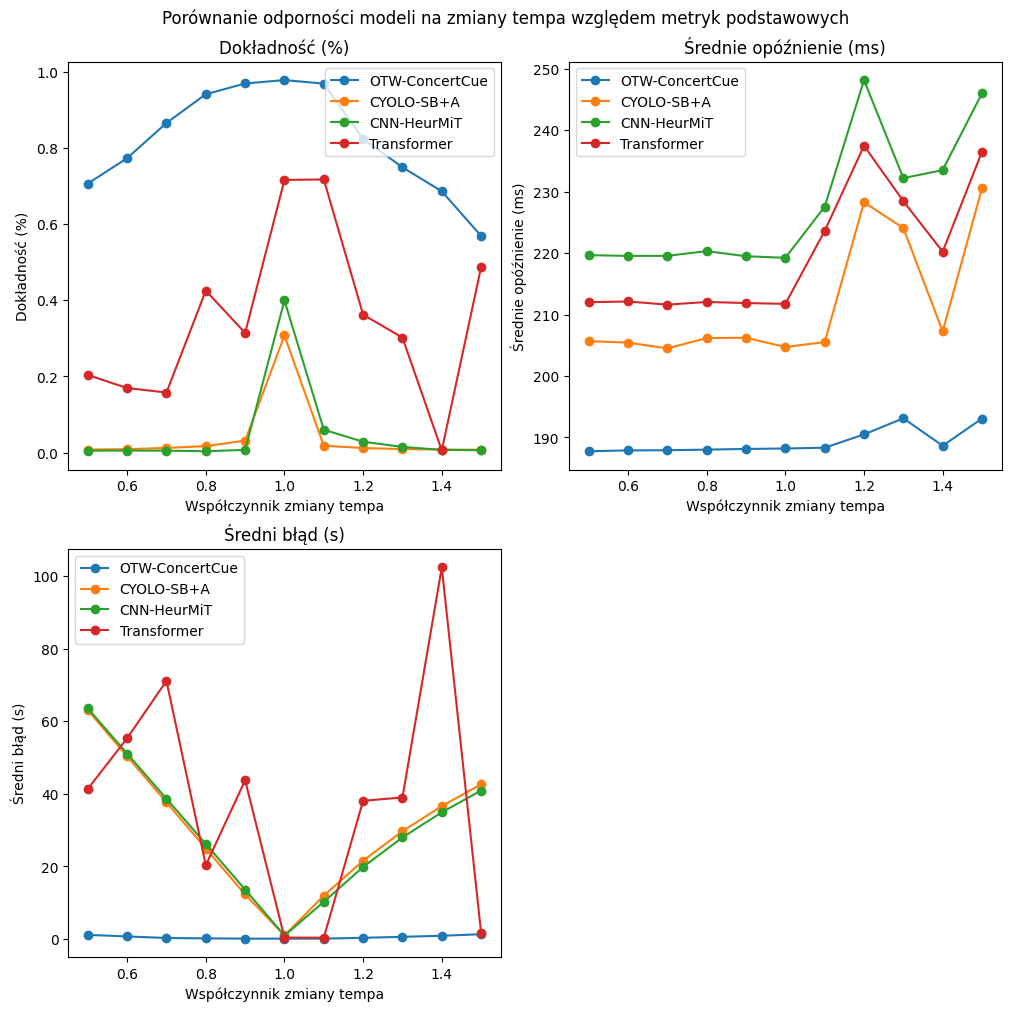

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), constrained_layout=True)

for i, metric_key in enumerate(BASIC_METRICS):
    plot_i, plot_j = i // 2, i % 2
    axes[plot_i, plot_j].set_title(METRIC_NAMES[metric_key])
    axes[plot_i, plot_j].set_xlabel("Współczynnik zmiany tempa")
    axes[plot_i, plot_j].set_ylabel(METRIC_NAMES[metric_key])

    for model_name in tempo_results:
        l, v = extract_labels_and_values_for_experiment_variations(tempo_results[model_name], metric_key)
        axes[plot_i, plot_j].plot(l, v, label=model_name, marker="o")

    axes[plot_i, plot_j].legend()

axes[1, 1].axis("off")
fig.suptitle("Porównanie odporności modeli na zmiany tempa względem metryk podstawowych")
fig.show()
fig.savefig(os.path.join(FIGURES_OUTPUT, "2.1_tempo.png"))

### 2.2. Pitch shift

In [ ]:
pitch_results = experiments_runner.test_pitch_robustness(
    pieces,
    results_path=os.path.join(RESULTS_OUTPUT, "2_pitch_robustness.csv"),
    verbose=True)

Beginning test for pitch shift -5...


Evaluating piece no. 1... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav):   0%|          | 0/2 [00:00<?, ?it/s]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s  ref_patches=4852


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav):  50%|█████     | 1/2 [02:32<02:32, 152.95s/it]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s  ref_patches=7816


...

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s
[PatchFormer] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi  shape=(128, 31265)  dur=312.7s  ref_patches=7816


Evaluating piece no. 2... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.wav): 100%|██████████| 2/2 [06:14<00:00, 187.22s/it]


Beginning test for pitch shift -2...


Evaluating piece no. 1... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav):   0%|          | 0/2 [00:00<?, ?it/s]

[HeurMiT] Reference: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi  shape=(128, 19409)  dur=194.1s


In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), constrained_layout=True)

for i, metric_key in enumerate(BASIC_METRICS):
    plot_i, plot_j = i // 2, i % 2
    axes[plot_i, plot_j].set_title(METRIC_NAMES[metric_key])
    axes[plot_i, plot_j].set_xlabel("Liczba przesuniętych półtonów")
    axes[plot_i, plot_j].set_ylabel(METRIC_NAMES[metric_key])

    for model_name in pitch_results:
        l, v = extract_labels_and_values_for_experiment_variations(pitch_results[model_name], metric_key)
        axes[plot_i, plot_j].plot(l, v, label=model_name, marker="o")

    axes[plot_i, plot_j].legend()

axes[1, 1].axis("off")
fig.suptitle("Porównanie odporności modeli na zmiany wysokości dostrojenia względem metryk podstawowych")
fig.show()
fig.savefig(os.path.join(FIGURES_OUTPUT, "2.2_pitch.png"))

### 2.3. Noise addition

In [ ]:
noise_results = experiments_runner.test_noise_robustness(
    pieces,
    results_path=os.path.join(RESULTS_OUTPUT, "2_noise_addition.csv"),
    verbose=True)

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), constrained_layout=True)

for i, metric_key in enumerate(BASIC_METRICS):
    plot_i, plot_j = i // 2, i % 2

    axes[plot_i, plot_j].set_title(METRIC_NAMES[metric_key])
    axes[plot_i, plot_j].set_xlabel("Współczynnik intensywności szumu (0=brak szumu, 1=tylko szum)")
    axes[plot_i, plot_j].set_ylabel(METRIC_NAMES[metric_key])

    for model_name in noise_results:
        l, v = extract_labels_and_values_for_experiment_variations(noise_results[model_name], metric_key)
        axes[plot_i, plot_j].plot(l, v, label=model_name, marker="o")

    axes[plot_i, plot_j].legend()

axes[1, 1].axis("off")
fig.suptitle("Porównanie odporności modeli na współistniejący szum względem metryk podstawowych")
fig.show()
fig.savefig(os.path.join(FIGURES_OUTPUT, "2.3_noise.png"))

## 3. Error recovery

This experiment illustrates how robust are the models to recovering the correct following after receiving a single major error compared to the reference track.
This is simulated by putting a 1-second long white noise in the tracked piece. After that, we observe the mean error per piece's second.

In [ ]:
noise_start = 60
error_recovery_results = experiments_runner.test_recovery_time(pieces, noise_start=noise_start, verbose=True)

In [ ]:
fig, ax = plt.subplots(nrows=4, figsize=(10, 6), constrained_layout=True)

for i, model_name in enumerate(error_recovery_results):
    recovery_results_for_model = error_recovery_results[model_name]
    l = [(i * evaluation.evaluator.CHUNK_SIZE) / evaluation.evaluator.SAMPLE_RATE for i in recovery_results_for_model.keys()]
    v = recovery_results_for_model.values()
    ax[i].plot(l, v, label=model_name)
    ax[i].set_xlabel("Czas utworu (s)")
    ax[i].set_ylabel("Średni błąd (s)")
    ax[i].axvline(x=noise_start, color='red', linestyle='--')
    ax[i].axvline(x=noise_start+15, color='red', linestyle='--')
    ax[i].set_title(model_name)

fig.suptitle("Średni błąd w zależności od czasu trwania utworu - porównanie modeli")
plt.savefig(os.path.join(FIGURES_OUTPUT, "3_recovery.png"))
plt.show()